In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("Không tìm thấy GPU. Model vẫn có thể chạy bằng CPU nhưng sẽ rất chậm.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
# Không nâng pandas, torch, torchvision hoặc các thư viện CUDA của Colab.

!pip install -q \
    "pandas==2.2.2" \
    "jedi>=0.16" \
    "transformers>=4.37,<5" \
    accelerate \
    huggingface_hub \
    safetensors \
    sentencepiece \
    einops \
    timm \
    pymupdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 80.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import os
import re
import json
import ast
from pathlib import Path

import fitz
import pandas as pd
import torch
import torchvision.transforms as T

from PIL import Image, ImageOps
from IPython.display import display
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

In [ ]:
MODEL_ID = "5CD-AI/Vintern-1B-v3_5"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    # T4 hỗ trợ float16 tốt hơn bfloat16.
    DTYPE = torch.float16
else:
    DTYPE = torch.float32

print("Thiết bị:", DEVICE)
print("Kiểu dữ liệu:", DTYPE)

Thiết bị: cuda
Kiểu dữ liệu: torch.float16


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    use_fast=False
)

model = AutoModel.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    use_flash_attn=False
)

model = model.eval().to(DEVICE)

print("Đã tải model:", MODEL_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- modeling_internvl_chat.py
- modeling_intern_vit.py
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention2 is not installed.


model.safetensors:   0%|          | 0.00/3.75G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

Đã tải model: 5CD-AI/Vintern-1B-v3_5


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transform(input_size=448):
    """
    Tạo pipeline chuẩn hóa ảnh trước khi đưa vào Vintern.
    """
    return T.Compose([
        T.Lambda(
            lambda img: img.convert("RGB")
            if img.mode != "RGB"
            else img
        ),
        T.Resize(
            (input_size, input_size),
            interpolation=InterpolationMode.BICUBIC
        ),
        T.ToTensor(),
        T.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])


def find_closest_aspect_ratio(
    aspect_ratio,
    target_ratios,
    width,
    height,
    image_size
):
    """
    Chọn cách chia ảnh phù hợp nhất với tỷ lệ ảnh gốc.
    """
    best_ratio_diff = float("inf")
    best_ratio = (1, 1)
    area = width * height

    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)

        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio

        elif ratio_diff == best_ratio_diff:
            target_area = (
                0.5
                * image_size
                * image_size
                * ratio[0]
                * ratio[1]
            )

            if area > target_area:
                best_ratio = ratio

    return best_ratio


def dynamic_preprocess(
    image,
    min_num=1,
    max_num=12,
    image_size=448,
    use_thumbnail=True
):
    """
    Chia ảnh hóa đơn thành nhiều vùng 448x448.

    max_num càng lớn:
    - Đọc chữ nhỏ tốt hơn.
    - Tốn nhiều VRAM hơn.
    """
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height

    target_ratios = {
        (i, j)
        for n in range(min_num, max_num + 1)
        for i in range(1, n + 1)
        for j in range(1, n + 1)
        if min_num <= i * j <= max_num
    }

    target_ratios = sorted(
        target_ratios,
        key=lambda x: x[0] * x[1]
    )

    target_ratio = find_closest_aspect_ratio(
        aspect_ratio=aspect_ratio,
        target_ratios=target_ratios,
        width=original_width,
        height=original_height,
        image_size=image_size
    )

    target_width = image_size * target_ratio[0]
    target_height = image_size * target_ratio[1]
    blocks = target_ratio[0] * target_ratio[1]

    resized_image = image.resize(
        (target_width, target_height),
        Image.Resampling.BICUBIC
    )

    processed_images = []

    for block_index in range(blocks):
        column = block_index % target_ratio[0]
        row = block_index // target_ratio[0]

        box = (
            column * image_size,
            row * image_size,
            (column + 1) * image_size,
            (row + 1) * image_size
        )

        processed_images.append(resized_image.crop(box))

    # Thêm một ảnh toàn cảnh để model hiểu bố cục tổng thể.
    if use_thumbnail and len(processed_images) > 1:
        thumbnail = image.resize(
            (image_size, image_size),
            Image.Resampling.BICUBIC
        )
        processed_images.append(thumbnail)

    return processed_images


def load_invoice_image(
    image_input,
    input_size=448,
    max_num=12
):
    """
    Nhận đường dẫn ảnh hoặc đối tượng PIL.Image.
    Trả về pixel_values dùng cho model.
    """
    if isinstance(image_input, (str, Path)):
        image = Image.open(image_input)
    elif isinstance(image_input, Image.Image):
        image = image_input
    else:
        raise TypeError(
            "image_input phải là đường dẫn ảnh hoặc PIL.Image.Image"
        )

    # Tự xoay ảnh theo thông tin EXIF của điện thoại.
    image = ImageOps.exif_transpose(image).convert("RGB")

    transform = build_transform(input_size=input_size)

    image_tiles = dynamic_preprocess(
        image=image,
        image_size=input_size,
        use_thumbnail=True,
        max_num=max_num
    )

    pixel_values = torch.stack([
        transform(tile)
        for tile in image_tiles
    ])

    pixel_values = pixel_values.to(
        device=DEVICE,
        dtype=DTYPE
    )

    return pixel_values

In [ ]:
INVOICE_PROMPT = """
<image>
Bạn là hệ thống OCR và trích xuất thông tin từ hóa đơn Việt Nam thành bảng markdown.
"""

In [ ]:
GENERATION_CONFIG = {
    "max_new_tokens": 2048,
    "do_sample": False,
    "num_beams": 3,
    "repetition_penalty": 1.2
}


@torch.inference_mode()
def run_vintern(
    image_input,
    prompt=INVOICE_PROMPT,
    max_num=12
):
    """
    Chạy Vintern trên một ảnh hóa đơn.
    """
    pixel_values = load_invoice_image(
        image_input=image_input,
        input_size=448,
        max_num=max_num
    )

    response = model.chat(
        tokenizer=tokenizer,
        pixel_values=pixel_values,
        question=prompt,
        generation_config=GENERATION_CONFIG,
        history=None,
        return_history=False
    )

    return response

In [ ]:
def extract_json_text(text):
    """
    Loại bỏ markdown và lấy phần JSON từ phản hồi model.
    """
    if not isinstance(text, str):
        text = str(text)

    text = text.strip()

    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"\s*```$",
        "",
        text
    )

    start = text.find("{")
    end = text.rfind("}")

    if start != -1 and end != -1 and end > start:
        return text[start:end + 1]

    return text


def parse_model_json(response):
    """
    Chuyển phản hồi của model thành Python dictionary.
    """
    json_text = extract_json_text(response)

    try:
        return json.loads(json_text)

    except json.JSONDecodeError as first_error:
        # Một số model đôi khi trả về dấu nháy đơn.
        try:
            result = ast.literal_eval(json_text)

            if isinstance(result, dict):
                return result

        except Exception:
            pass

        return {
            "parse_error": str(first_error),
            "raw_model_response": response
        }

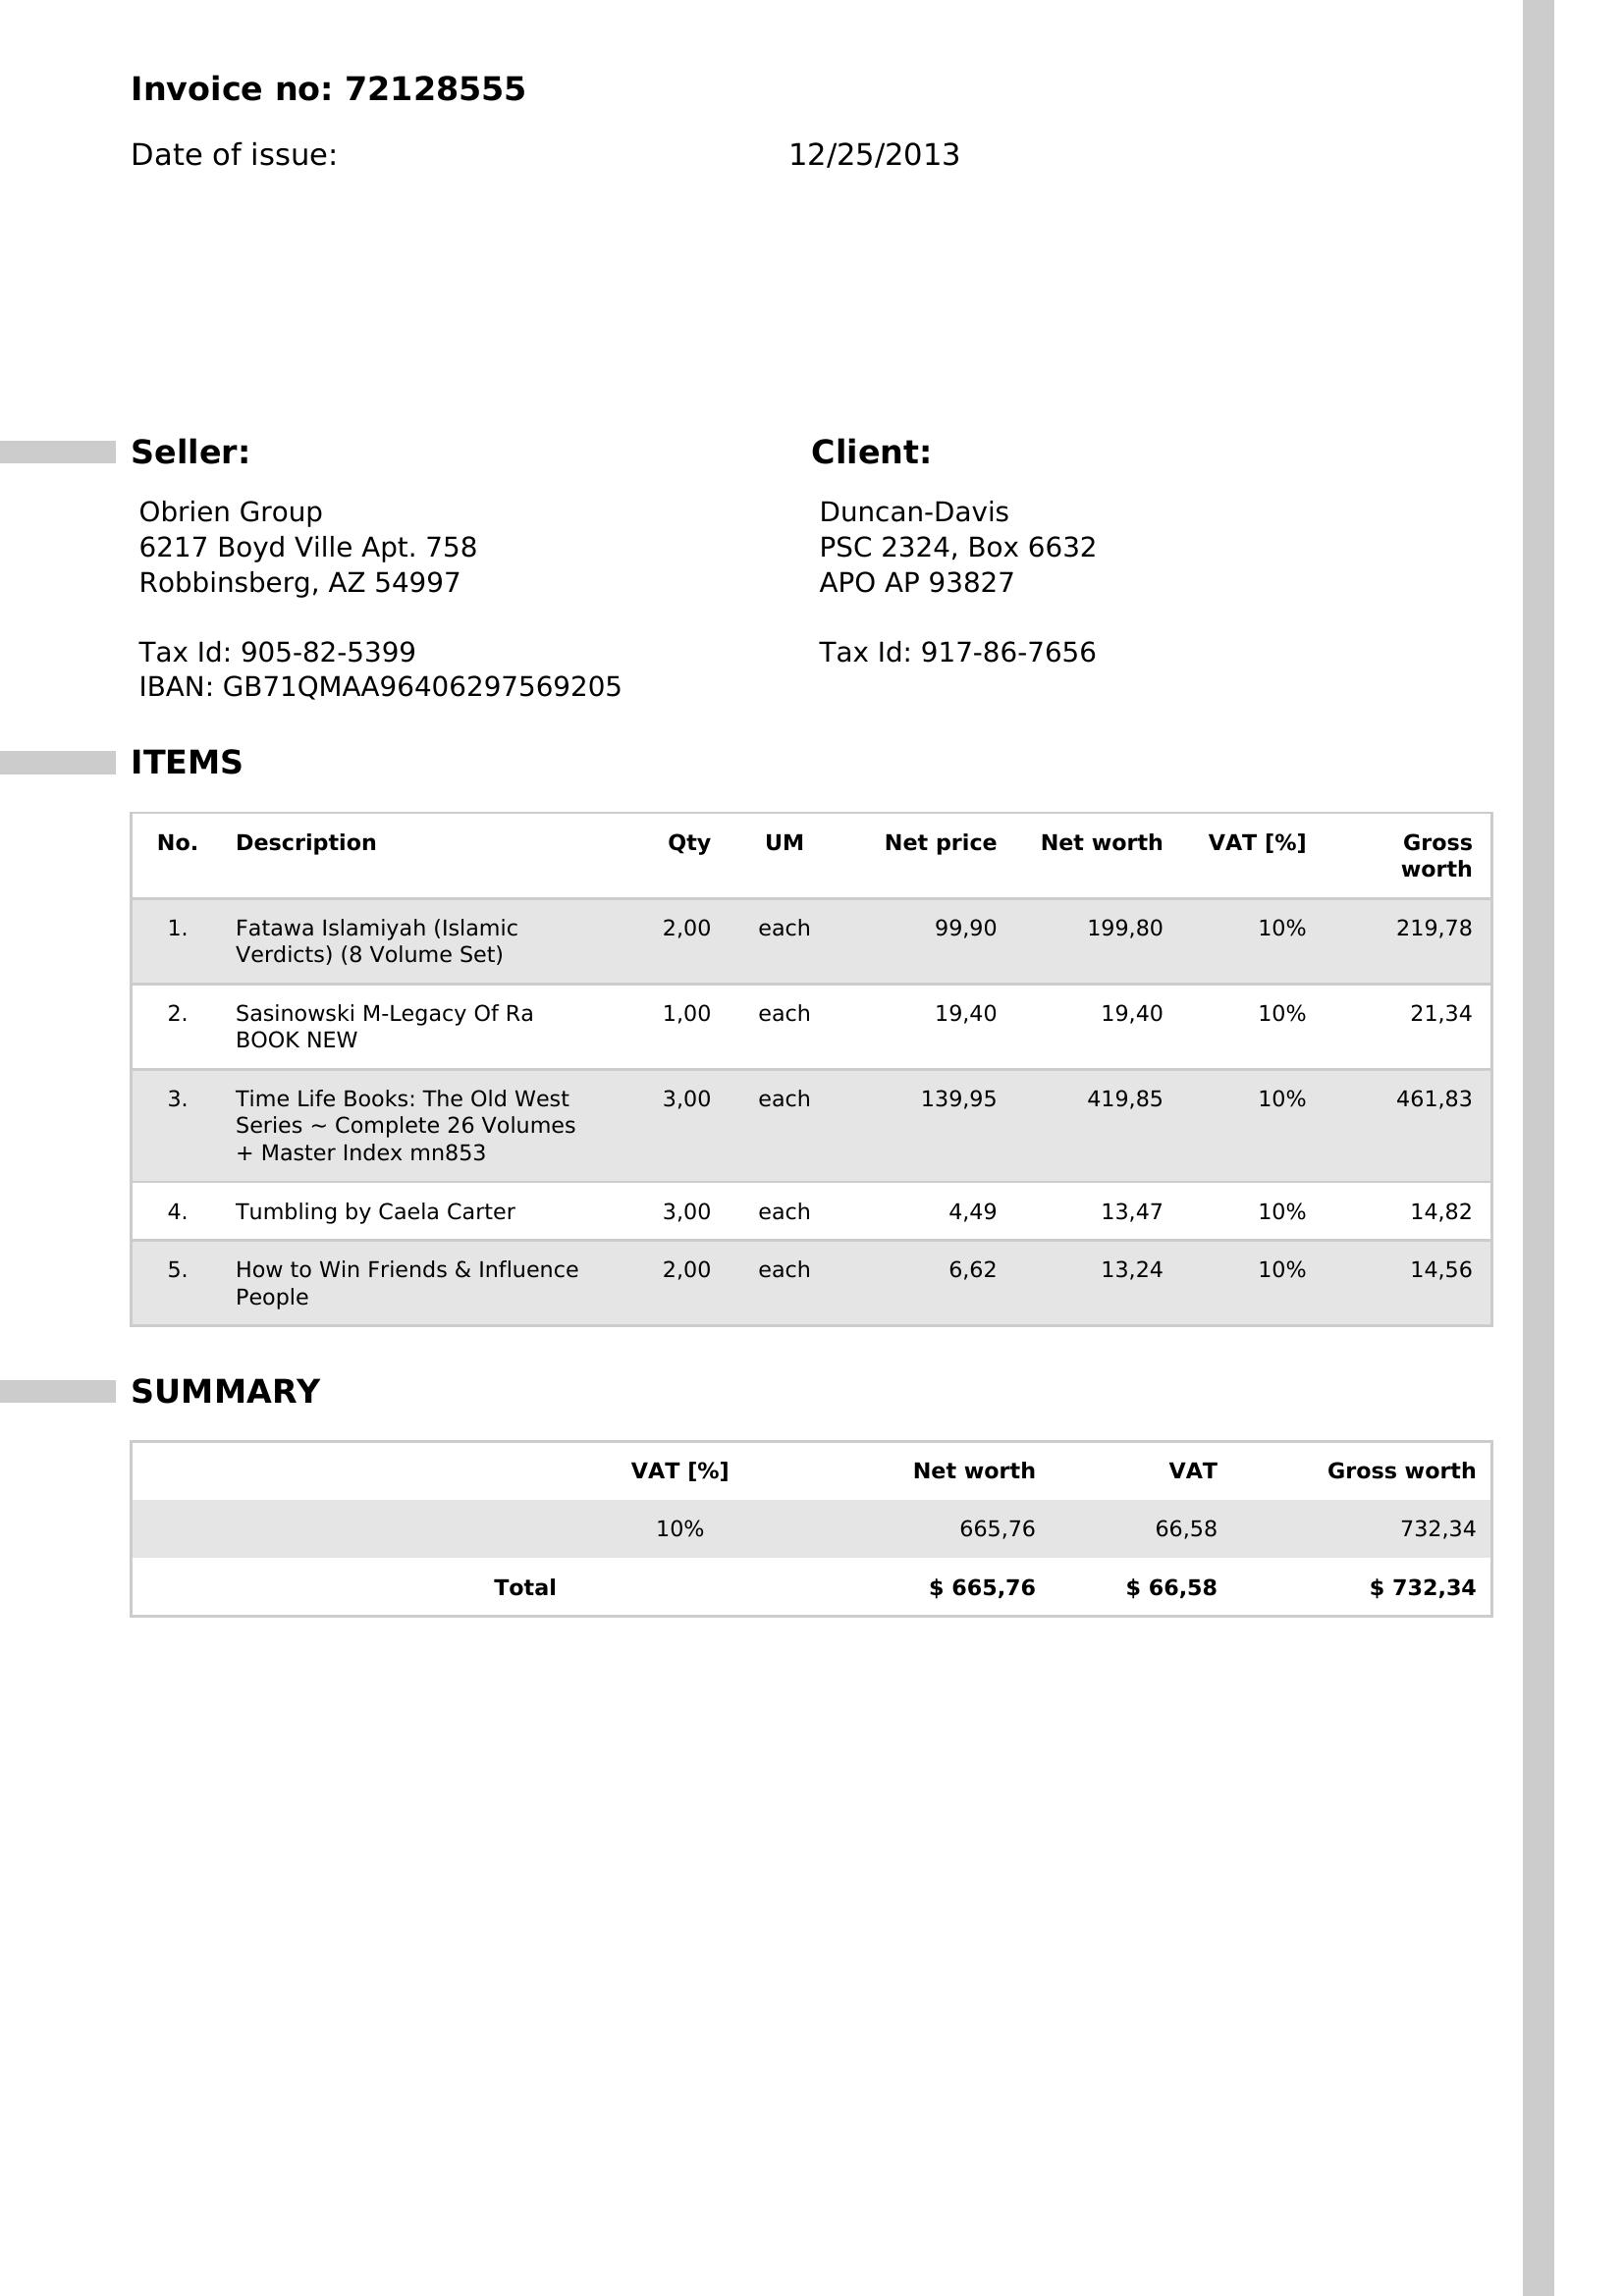

In [ ]:
# from google.colab import files

# uploaded = files.upload()

# IMAGE_PATH = next(iter(uploaded.keys()))
# print("Ảnh đã chọn:", IMAGE_PATH)

# display(Image.open(IMAGE_PATH))

IMAGE_PATH = '/content/drive/MyDrive/archive/batch_1/batch_1/batch1_1/batch1-0006.jpg'

display(Image.open(IMAGE_PATH))

In [ ]:
raw_response = run_vintern(
    image_input=IMAGE_PATH,
    prompt=INVOICE_PROMPT,
    max_num=12
)

print(raw_response)

Token indices sequence length is longer than the specified maximum sequence length for this model (1874 > 1700). Running this sequence through the model will result in indexing errors
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


# Hóa đơn số 72128555

**Ngày lập hóa đơn:** 12/25/2013

**Sản phẩm:**

| STT | Tên sản phẩm | Mô tả | Số lượng | Giá tiền (USD) | Giá trị (VNĐ) | VAT (%) | Tổng giá trị (VNĐ) |
|---|---|---|---|---|---|---|---| 
| 1 | Fatawa Islamiyah (Islamic Verdicts) (8 Volume Set) | 2,00 | 2,00 | 99,90 | 199,80 | 10% | 219,78 |
| 2 | Sasinowski M-Legacy Of Ra Book New | 1,00 | 1,00 | 19,40 | 19,40 | 10% | 21,34 |
| 3 | Time Life Books: The Old West Series - Complete 26 volumes + Master Index mn853 | 3,00 | 3,00 | 139,95 | 419,85 | 10% | 461,83 |
| 4 | Tumbling by Caela Carter | 3,00 | 3,00 | 4,49 | 13,47 | 10% | 14,82 |
| 5 | How to Win Friends & Influence People | 2,00 | 2,00 | 6,62 | 13,24 | 10% | 14,56 |

**Tổng cộng:**

| STT | Tên sản phẩm | Mô tả | Số lượng | Giá tiền (USD) | Giá trị (VNĐ) | VAT (%) | Tổng giá trị (VNĐ) |
|---|---|---|---|---|---|---|---| 
| 1 | Fatawa Islamiyah (Islamic Verdicts) (8 Volume Set) | 2,00 | 2,00 | 99,90 | 199,80 | 10% | 219,78 |
| 2 | Sasinowski M-Legacy Of Ra 

## Đọc hóa đơn trên pdf

In [ ]:
def pdf_to_images(
    pdf_path,
    dpi=200
):
    """
    Chuyển từng trang PDF thành PIL.Image.
    """
    document = fitz.open(pdf_path)
    images = []

    zoom = dpi / 72
    matrix = fitz.Matrix(zoom, zoom)

    for page_number in range(len(document)):
        page = document.load_page(page_number)

        pixmap = page.get_pixmap(
            matrix=matrix,
            alpha=False
        )

        image = Image.frombytes(
            "RGB",
            (pixmap.width, pixmap.height),
            pixmap.samples
        )

        images.append(image)

    document.close()

    return images

Số trang: 1


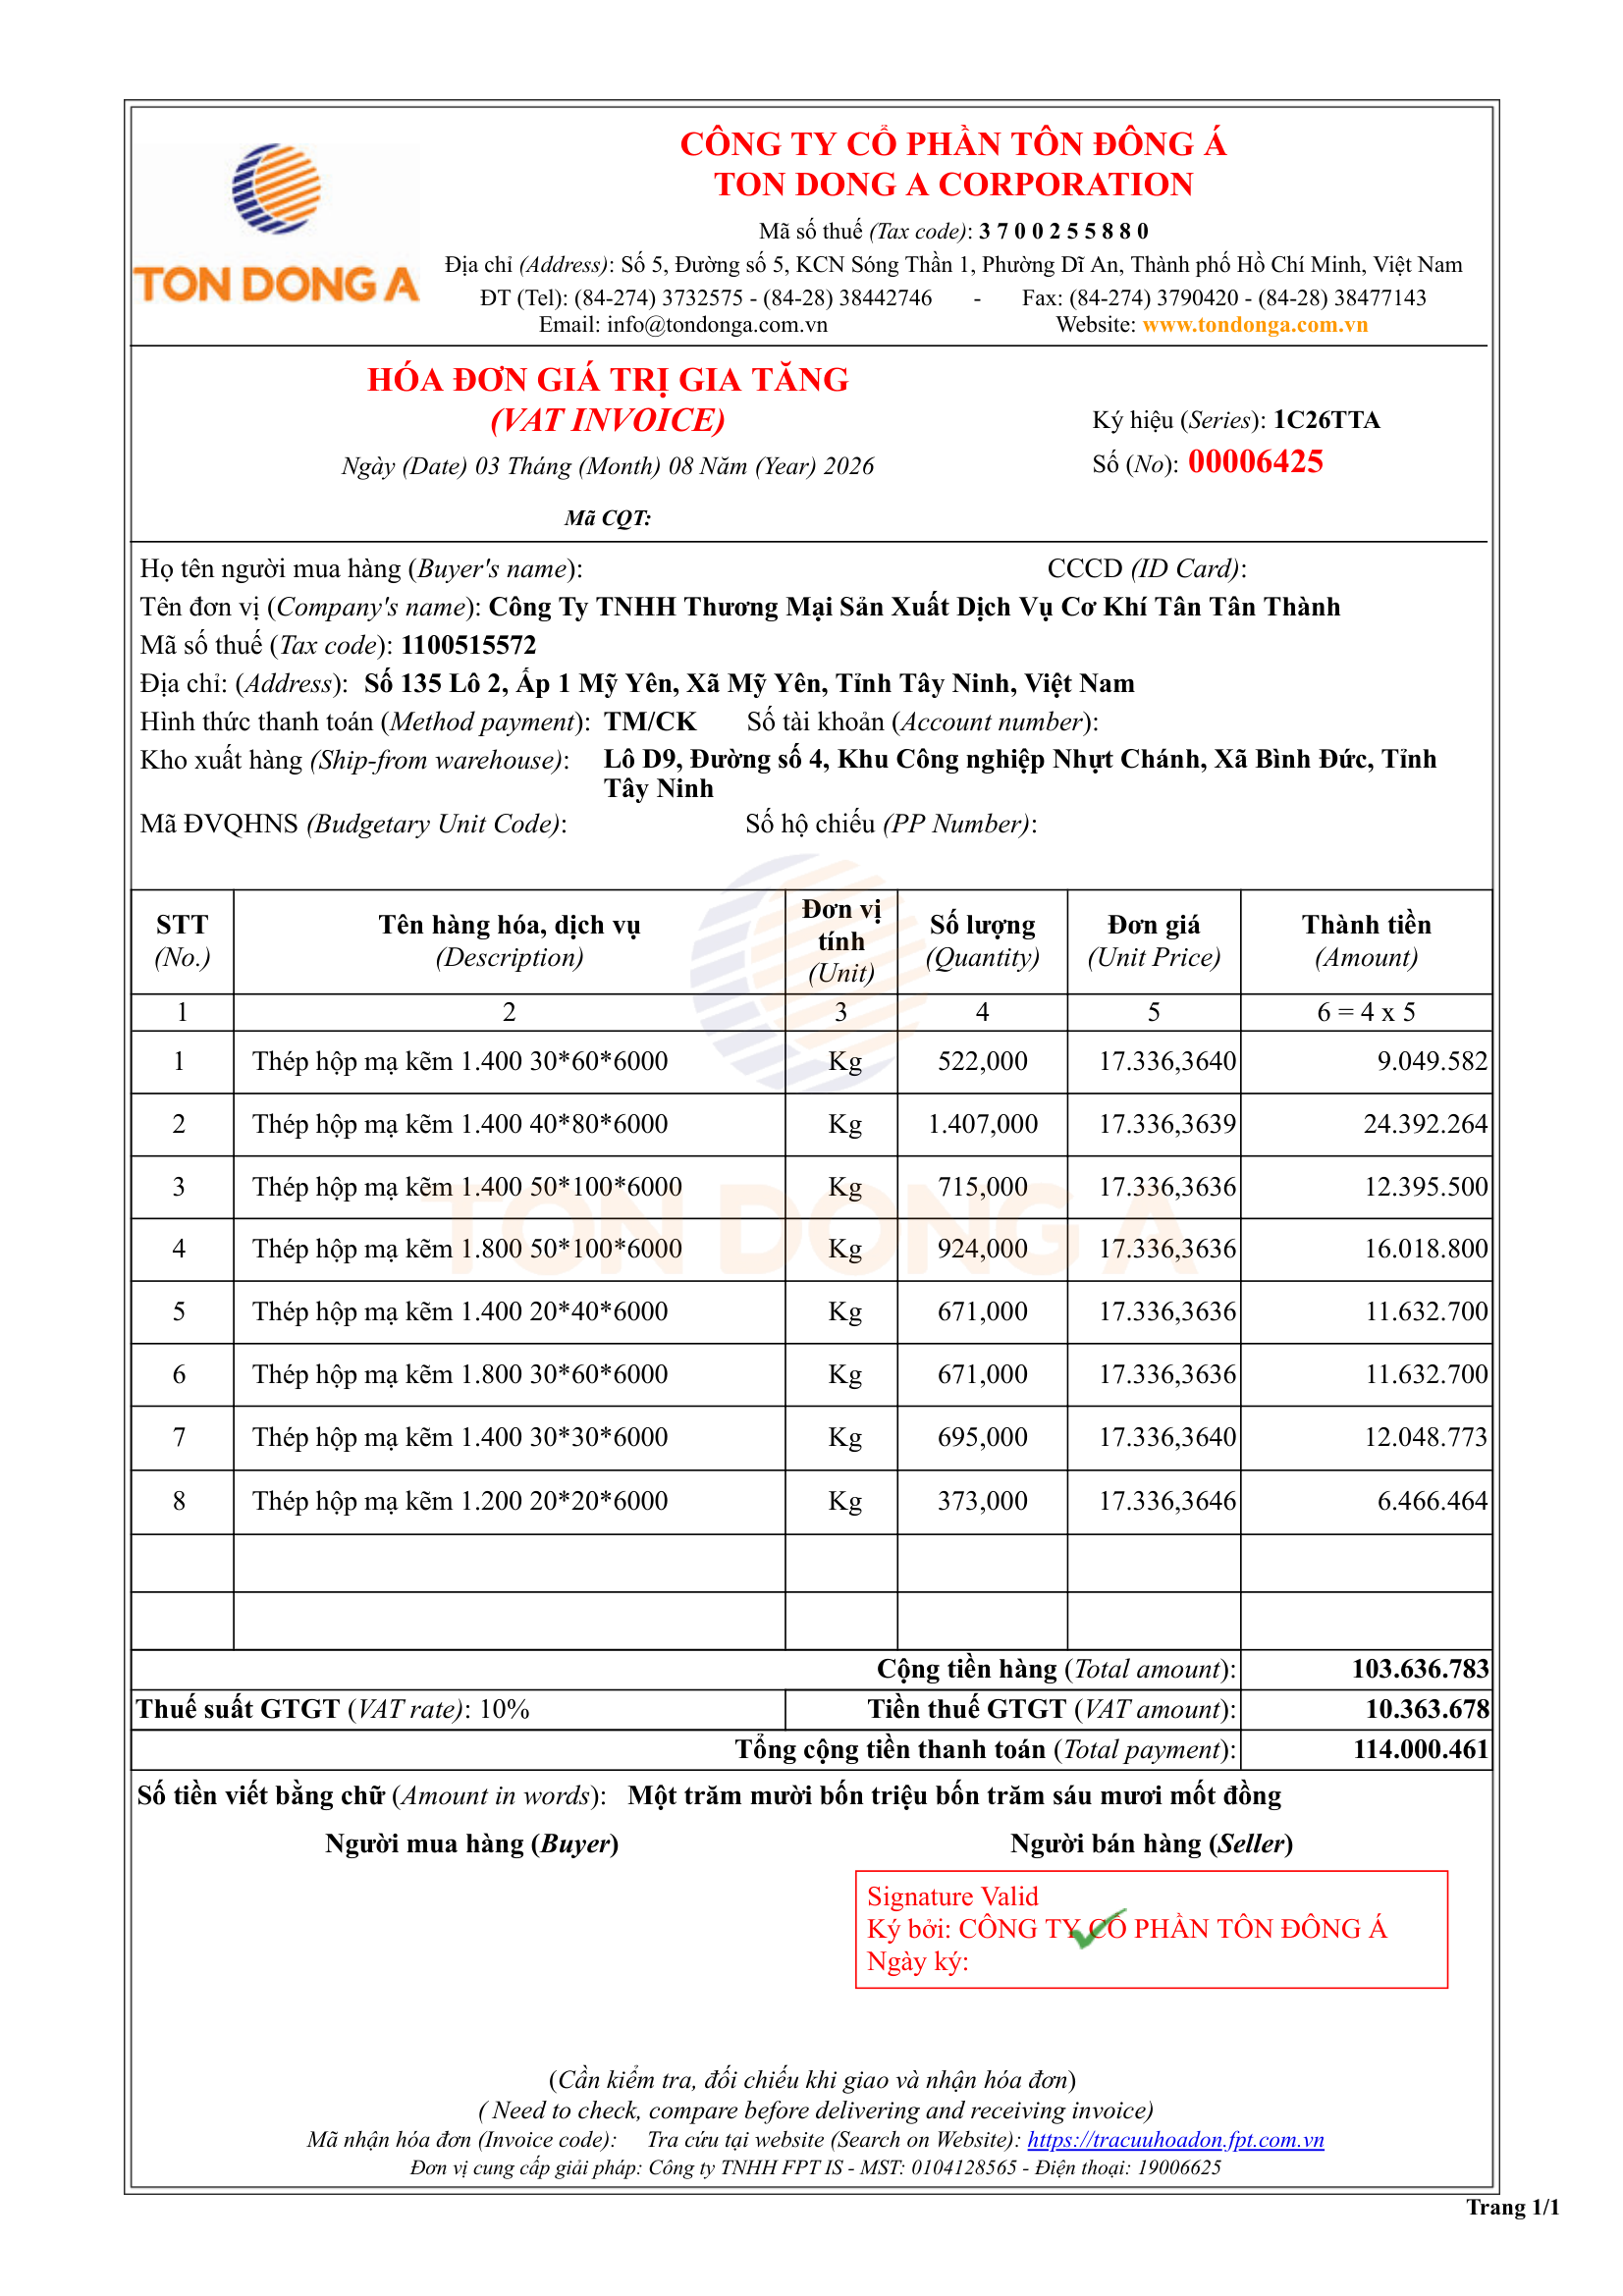

In [ ]:
PDF_PATH = "/content/4f30c1ad-c130-47a0-b164-41ad070218f2.pdf"

pdf_images = pdf_to_images(
    PDF_PATH,
    dpi=200
)

print("Số trang:", len(pdf_images))

display(pdf_images[0])

In [ ]:
pdf_results = []

for page_index, page_image in enumerate(pdf_images, start=1):
    print(f"Đang xử lý trang {page_index}/{len(pdf_images)}")

    raw_response = run_vintern(
        image_input=page_image,
        prompt=INVOICE_PROMPT,
        max_num=12
    )

    page_data = parse_model_json(raw_response)

    pdf_results.append({
        "page": page_index,
        "data": page_data
    })

print("Đã xử lý xong.")
print(raw_response)

Đang xử lý trang 1/1


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Đã xử lý xong.
# Hóa đơn giá trị gia tăng (VAT Invoice)

**Thông tin công ty:**
* Tên công ty: Công ty Cổ phần Tôn Đông Á
* Mã số thuế: 3700255880
* Địa chỉ: Số 5, Đường số 5, KCN Sóng Thần 1, Phường Dĩ An, Thành phố Hồ Chí Minh, Việt Nam
* Điện thoại: (84-274) 3732575 - (84-28) 38442746
* Fax: (84-274) 3790420 - (84-28) 38477143
* Email: info@tondonga.com.vn
* Website: www.tondonga.com.vn

**Thông tin hóa đơn:**
* Ngày: 03 tháng 08 năm 2026
* Mã CQT: 1C26TTA
* Số hóa đơn: 00006425

**Thông tin khách hàng:**
* Họ tên: (Không ghi rõ)
* Tên đơn vị: Công Ty TNHH Thương Mại Sản Xuất Dịch Vụ Cơ Khí Tân Tân Thành
* Mã số thuế: 1100515572
* Địa chỉ: Số 135 Lô 2, Ấp 1 Mỹ Yên, Xã Mỹ Yên, Tỉnh Tây Ninh, Việt Nam
* Hình thức thanh toán: TM/CK
* Số tài khoản: (Không ghi rõ)
* Kho xuất hàng: Lô D9, Đường số 4, Khu Công nghiệp Nhựt Chánh, Xã Bình Đức, Tỉnh Tây Ninh

**Thông tin hàng hóa:**
| STT | Tên hàng hóa, dịch vụ | Đơn vị | Số lượng | Đơn giá | Thành tiền |
|---|---|---|---|---|---| 
| 1 | Thé

In [ ]:
print(
    json.dumps(
        pdf_results,
        ensure_ascii=False,
        indent=2
    )
)

output_pdf_json = Path(PDF_PATH).with_suffix(".json")

with open(
    output_pdf_json,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        pdf_results,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Đã lưu:", output_pdf_json)

[
  {
    "page": 1,
    "data": {
      "parse_error": "Expecting value: line 1 column 1 (char 0)",
      "raw_model_response": "# Hóa đơn siêu thị\n\n**Thông tin khách hàng:**\n* Tên: Aaron Hawkins\n* Địa chỉ: 90004, Los Angeles, California, United States\n\n**Thông tin hóa đơn:**\n* Số hóa đơn: 36652\n* Ngày: 12/05/2012\n* Phương thức vận chuyển: Standard Class\n* Tổng số tiền: $17.15\n\n**Thông tin sản phẩm:**\n* Mã sản phẩm: OFF-PA-4014\n* Loại sản phẩm: EcoTones Memo Sheets\n* Số lượng: 2\n* Giá mỗi sản phẩm: $8.00\n* Tổng cộng: $16.00\n\n**Ghi chú:**\n* Thank you for your business!\n* Order ID: CA-2012-AH10030140-41041"
    }
  }
]
Đã lưu: /content/drive/MyDrive/1000+ PDF_Invoice_Folder/1000+ PDF_Invoice_Folder/invoice_Aaron Hawkins_36652.json
